# Construyendo sistemas ópticos — trenes estigmáticos con restricciones enchufables

Cuatro sistemas *potentes* de solo **lentes y aire**, con **vidrios reales** del
catálogo Sellmeier, diseñados con el optimizador de restricciones componibles de
`raytracer.optimize`:

| sistema | lentes | vidrios | especificación |
|---|---|---|---|
| **Objetivo de telescopio** | 2 | N-BK7 + N-F2 | D = 52 mm, EFL ≈ 400 mm, acromático F/C |
| **Objetivo de microscopio** | 3 | N-LAK21 / N-SF11 / N-BK7 | 20×, NA 0.25, campo plano, sin distorsión |
| **Ultra-gran-angular** | 2 | N-SF11 + N-BK7 | objeto **virtual** (d₀ > 0): campo físico ±43° |
| **Proyector** | 4 | N-SK16 / N-F2 / N-BK7 / N-SK4 | diapositiva → pantalla a 2 m, ~32× |

Cada restricción es un objeto que produce su bloque de residuales y se enchufa a
`optimize_train` en cualquier combinación: `Aplanatism` (condición del seno,
M − 1 por rayo), `Distortion` (alturas de imagen contra el mapa lineal),
`FlatImageSurface` (sagita de la superficie imagen aplanática),
`TargetMagnification` (fija g_t) y `AxialColor` (foco F/C sobre el plano de
diseño, con la dispersión *real* de los materiales). Escribir una nueva es
subclasear `Constraint` — la sección del ultra-gran-angular lo hace en vivo,
porque un objeto virtual no admite el trazado estándar desde el plano objeto.

Al final: el **microscopio imprimible** — tres lentes del mismo material, la
resina Formlabs Clear V4, con su dispersión medida leída de
`data/materials/formlabs_resins.csv` mediante `raytracer.io.read_materials`.

Los óptimos vienen de búsquedas multiarranque (~minutos, guion en
`docs/design_systems.py`) y viven como **archivos de datos** en
`data/optical_systems/<clase>/*.json`; cada celda los carga con
`raytracer.io.read_train`, los re-pule en segundos con `least_squares` y
**verifica los números en vivo** sobre rayos exactos. Los cuerpos de lente
de las figuras se deducen de la secuencia de medios y se colorean por
densidad óptica, automáticamente.

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from importlib import resources

from raytracer.design import StigmaticTrain
from raytracer.io import read_materials, read_train
from raytracer.optics.materials import AIR, default_materials, sellmeier_glass
from raytracer.optimize import (
    Aplanatism, AxialColor, Constraint, Distortion, EvaluationContext,
    FlatImageSurface, TargetMagnification, optimize_train,
)
from raytracer.analysis import (
    aplanatic_image_surface, aplanatism_map, aplanatism_report, distortion_grid,
    spot_data,
)
from raytracer.propagation import (
    FieldPoint, PupilSampling, SequentialTracer, trace_from_object, trace_pupil,
)
from raytracer.viz import plots
from raytracer.viz.bodies import draw_system

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

DATA = resources.files("raytracer").parent / "data"
LIB = read_materials(DATA / "materials/formlabs_resins.csv", into=default_materials())
BK7 = sellmeier_glass("N-BK7")
WL = 0.58756   # línea d

POLISH = dict(diff_step=1e-4, xtol=1e-14, ftol=1e-14, gtol=1e-14, max_nfev=60)
FIELD_COLORS = ["#d62728", "#2878b5", "#1a6e3c"]


def draw_train(ax, train, fields, na, title, *, launch=None, rays=7,
               xlim=None, ylim=None):
    """Render estándar (cuerpos por densidad + abanicos) más el título."""
    draw_system(ax, train, fields=fields, na=na, rays=rays, launch=launch,
                xlim=xlim, ylim=ylim)
    ax.set_title(title, fontsize=10)

## 1. Objetivo de telescopio — 2 lentes, acromático y aplanático

Doblete espaciado N-BK7 + N-F2, apertura 52 mm, objeto a 10⁶ mm (el sustituto
finito de infinito que usa todo el paquete), foco en +400 mm. Restricciones:
`Aplanatism` + `AxialColor`. El reparto de potencias entre corona y flint es
exactamente el grado de libertad que gasta un acromático clásico — y aquí lo
mueven las conjugadas intermedias, sin tocar la estigmaticidad, que es exacta
por construcción en la línea d.

In [2]:
telescope0 = read_train(
    DATA / "optical_systems/telescopes/bk7_f2_achromatic_doublet.json", materials=LIB)
print("medios:", [m.name for m in telescope0.media])

TEL_NA = 2.6e-5
telescope = optimize_train(
    telescope0,
    [Aplanatism(), AxialColor(weight=0.05)],
    na_object_sine=TEL_NA, samples=11, bounds=(-2e5, 2e5), **POLISH,
).train

ctx = EvaluationContext(telescope, na_object_sine=TEL_NA, samples=9)
color = AxialColor().residuals(ctx)
singlet = StigmaticTrain(
    media=(AIR, BK7, AIR), vertices=(0.0, 9.0),
    conjugates=(-1.0e6, 5000.0, 400.0), wavelength_um=WL, semidiameter=26.0)
color_singlet = AxialColor().residuals(
    EvaluationContext(singlet, na_object_sine=TEL_NA, samples=9))
tel_fields = [0.0, 6000.0, 13000.0]            # 0° / 0.34° / 0.75°
tel_locus = aplanatic_image_surface(telescope, tel_fields, na_object_sine=TEL_NA)
print(f"(M-1)_RMS = {ctx.report().map_rms:.2e}   gt = {telescope.gt:+.3e}")
print(f"color axial F/C: {color[0]:+.4f} / {color[1]:+.4f} mm"
      f"   (un singlete BK7 igual de potente: {color_singlet[0]:+.2f} / {color_singlet[1]:+.2f} mm)")
print(f"blur en 0 / 0.34° / 0.75° de campo: "
      f"{np.array2string(tel_locus.blur_rms_um, precision=2)} µm"
      f"   (radio de Airy a f/7.7 ≈ 5.5 µm)")

medios: ['AIR', 'N-BK7', 'AIR', 'N-F2', 'AIR']


(M-1)_RMS = 4.66e-05   gt = -3.901e-04
color axial F/C: +0.0926 / +0.2466 mm   (un singlete BK7 igual de potente: -4.20 / +1.90 mm)
blur en 0 / 0.34° / 0.75° de campo: [8.00e-12 3.46e-01 1.50e+00] µm   (radio de Airy a f/7.7 ≈ 5.5 µm)


## 2. Objetivo de microscopio — 3 lentes, 20×, NA 0.25

Tres vidrios (corona de lantano, flint denso, corona), objeto a 6 mm de
distancia de trabajo, imagen a 170 mm. Cuatro restricciones a la vez:
aplanatismo, aumento fijado en −20×, distorsión nula y campo plano — los
cinco grados de libertad (las conjugadas intermedias) se reparten entre
ellas.

In [3]:
microscope0 = read_train(
    DATA / "optical_systems/microscopes/lak21_sf11_bk7_20x.json", materials=LIB)
print("medios:", [m.name for m in microscope0.media])

MIC_NA, MIC_FIELDS = 0.25, (0.15, 0.3)
microscope_fit = optimize_train(
    microscope0,
    [Aplanatism(),
     TargetMagnification(value=-20.0, weight=0.05),
     Distortion(heights=MIC_FIELDS, weight=1.0),
     FlatImageSurface(heights=(0.0, *MIC_FIELDS), weight=1.0)],
    na_object_sine=MIC_NA, samples=11, bounds=(-5e3, 5e3), **POLISH,
)
microscope = microscope_fit.train
ctx = EvaluationContext(microscope, na_object_sine=MIC_NA, samples=9)
dist = Distortion(heights=MIC_FIELDS).residuals(ctx)
locus = microscope_fit.image_surface
airy_um = 0.61 * WL / (MIC_NA / abs(microscope.gt))
print(f"(M-1)_RMS = {ctx.report().map_rms:.2e}   gt = {microscope.gt:+.4f}")
print(f"distorsión en 0.15/0.3 mm de objeto: {np.array2string(dist*100, precision=4)} %")
print(f"sagita de la superficie imagen: {locus.max_sagitta:.5f} mm")
print(f"blur en campo {np.array2string(locus.blur_rms_um, precision=2)} µm"
      f"   (radio de Airy en imagen ≈ {airy_um:.1f} µm)")

medios: ['AIR', 'N-LAK21', 'AIR', 'N-SF11', 'AIR', 'N-BK7', 'AIR']


(M-1)_RMS = 2.56e-04   gt = -19.9999
distorsión en 0.15/0.3 mm de objeto: [0.0114 0.1253] %
sagita de la superficie imagen: 0.00018 mm
blur en campo [1.02e-11 1.44e+00 5.15e+00] µm   (radio de Airy en imagen ≈ 28.7 µm)


## 3. Ultra-gran-angular — objeto virtual, campo físico ±43°

La idea: con **d₀ > 0** el "objeto" es un punto *virtual* A detrás de la
primera superficie. Todo rayo que entre **apuntando a A** — al ángulo que sea —
pertenece al cono estigmático y aterriza perfectamente en el foco. Un tren de
Descartes con conjugada de objeto positiva es, por construcción, un
gran-angular perfecto para su pupila virtual.

La *apertura física* la acota la geometría de las piezas: la cara trasera de
la lente SF11 cruza la cara frontal de la BK7 en h = 5.86 mm, y más allá de
±44° los rayos alcanzan las caras donde la descripción ya no define ningún
medio — la cadena matemática sigue siendo estigmática, pero no hay vidrio que
refracte. El escaparate se queda en ±43° (86° de campo total), todo sobre
vidrio real.

El plano objeto queda *dentro* del sistema, así que `trace_from_object` no
sirve: los rayos se lanzan desde un plano delante de la lente, convergiendo
hacia A. La restricción se define aquí mismo, subclaseando `Constraint` —
el mapa M de Silva-Lora & Torres se evalúa con las alturas de impacto
trazadas (`aplanatism_map(..., from_heights=True)`), y nunca le importó si la
conjugada es real o virtual.

In [4]:
class VirtualObjectAplanatism(Constraint):
    """Condición del seno para un tren con objeto virtual (d0 > 0)."""

    def __init__(self, sines, launch_z=-25.0, weight=1.0):
        self.sines = tuple(sines)
        self.launch_z = launch_z
        self.weight = weight

    def size(self, context):
        return len(self.sines)

    def residuals(self, context):
        train = context.train
        tracer = SequentialTracer(train.to_system())
        a = train.conjugates[0]
        out = np.full(len(self.sines), 1e3)
        heights, kept = [], []
        for i, sine in enumerate(self.sines):
            t = sine / np.sqrt(1.0 - sine * sine)
            origin = np.array([0.0, (a - self.launch_z) * t, self.launch_z])
            direction = np.array([0.0, -t, 1.0]) / np.hypot(t, 1.0)
            r = tracer.trace(origin, direction, keep_path=True)
            if not r.ok:
                continue
            heights.append(np.abs(r.path[1:-1, 1]))
            kept.append(i)
        if kept:
            m = aplanatism_map(train, np.array(heights), from_heights=True)
            out[np.array(kept)] = m - 1.0
        return self.weight * out

In [5]:
# El óptimo viene de la búsqueda multiarranque y vive como archivo de datos,
# con las conjugadas a precisión completa. Se VERIFICA tal cual, dentro del
# campo físico ±43°: más allá de ±44° los impactos superan el cruce de caras
# (h = 5.86 mm) y no hay medio definido que refracte.
ultrawide = read_train(
    DATA / "optical_systems/ultrawide/sf11_bk7_virtual_object.json", materials=LIB)
print("medios:", [m.name for m in ultrawide.media])

UW_SINES = np.sin(np.deg2rad(np.linspace(5.0, 43.0, 11)))
uw_constraint = VirtualObjectAplanatism(UW_SINES)

ctx = EvaluationContext(ultrawide, na_object_sine=0.1, samples=5)
residuals = uw_constraint.residuals(ctx)
tracer = SequentialTracer(ultrawide.to_system())
print("altura de imagen de rayos apuntados a A (estigmatismo a todo ángulo):")
for deg in (15.0, 30.0, 43.0):
    t = np.tan(np.deg2rad(deg))
    origin = np.array([0.0, (8.0 + 25.0) * t, -25.0])
    direction = np.array([0.0, -t, 1.0]) / np.hypot(t, 1.0)
    r = tracer.trace(origin, direction)
    print(f"  {deg:4.0f}°:  |y_imagen| = {abs(r.image_point[1])*1e3:9.4f} µm   ok={r.ok}")
print(f"condición del seno 5–43°: |M-1| RMS = {np.sqrt(np.mean(residuals**2)):.3e}"
      f"  (dos lentes para un cono de 86°: el estigmatismo es exacto, el"
      f" aplanatismo queda al 1.4 %)")

medios: ['AIR', 'N-SF11', 'AIR', 'N-BK7', 'AIR']
altura de imagen de rayos apuntados a A (estigmatismo a todo ángulo):
    15°:  |y_imagen| =    0.0000 µm   ok=True
    30°:  |y_imagen| =    0.0000 µm   ok=True
    43°:  |y_imagen| =    0.0000 µm   ok=True
condición del seno 5–43°: |M-1| RMS = 1.416e-02  (dos lentes para un cono de 86°: el estigmatismo es exacto, el aplanatismo queda al 1.4 %)


## 4. Proyector — 4 lentes, diapositiva → pantalla a 2 m

Ocho superficies, siete conjugadas libres, y cuatro restricciones compitiendo:
aplanatismo, aumento (objetivo −45×), distorsión nula en pantalla y color
axial F/C. Dos lecciones honestas salieron de este diseño:

1. **La pupila de referencia importa.** Medida contra el vértice frontal, la
   distorsión de un proyector rápido es enorme por pura convención; el
   parámetro `aim_z` de las restricciones de campo la coloca dentro del
   barril (`aim_z = 17`), donde vive la pupila natural del sistema.
2. **Las conjugadas no lo compran todo.** Con vértices y vidrios fijos, la
   familia estigmática satura antes del pliego completo: el optimizador
   entrega ~−32× con ~1 % de distorsión y declara el color residual. Los
   vértices como grados de libertad adicionales son la extensión natural.

In [6]:
projector0 = read_train(
    DATA / "optical_systems/projectors/sk16_f2_bk7_sk4_slide_projector.json",
    materials=LIB)
print("medios:", [m.name for m in projector0.media])

PRO_NA, PRO_FIELDS, PRO_AIM = 0.10, (3.0, 6.0), 17.0
projector_fit = optimize_train(
    projector0,
    [Aplanatism(),
     TargetMagnification(value=-45.0, weight=0.02),
     Distortion(heights=PRO_FIELDS, weight=2.0, aim_z=PRO_AIM),
     AxialColor(weight=0.05)],
    na_object_sine=PRO_NA, samples=11, bounds=(-6e3, 6e3), **POLISH,
)
projector = projector_fit.train
ctx = EvaluationContext(projector, na_object_sine=PRO_NA, samples=9)
dist = Distortion(heights=PRO_FIELDS, aim_z=PRO_AIM).residuals(ctx)
color = AxialColor().residuals(ctx)
print(f"(M-1)_RMS = {ctx.report().map_rms:.2e}   gt = {projector.gt:+.3f}")
print(f"distorsión en pantalla: {np.array2string(dist*100, precision=4)} %")
print(f"color axial F/C en pantalla: {color[0]:+.3f} / {color[1]:+.3f} mm "
      f"(profundidad de foco geométrica en pantalla ≈ ±{0.02/ (PRO_NA/45)**2 *1e-3:.0f} mm)")
print(f"blur en la pantalla: {np.array2string(projector_fit.image_surface.blur_rms_um, precision=1)} µm")

medios: ['AIR', 'N-SK16', 'AIR', 'N-F2', 'AIR', 'N-BK7', 'AIR', 'N-SK4', 'AIR']


(M-1)_RMS = 5.20e-03   gt = -31.628
distorsión en pantalla: [ 0.7823 -1.4091] %
color axial F/C en pantalla: +14.943 / +41.243 mm (profundidad de foco geométrica en pantalla ≈ ±4 mm)
blur en la pantalla: [5.6e-11 1.0e+03 2.3e+03] µm


## 5. Los cuatro trazados, sus spots y sus mallas de distorsión

Los cortes meridionales con el plano imagen punteado; los spot diagrams en el
borde de campo de cada sistema; y las mallas de distorsión (rayo principal por
el diafragma de cada diseño). El ultra-gran-angular no aparece en spots ni
mallas: su objeto es virtual — su mapa campo → imagen se verificó punto a
punto en §3, y es estigmático exacto.

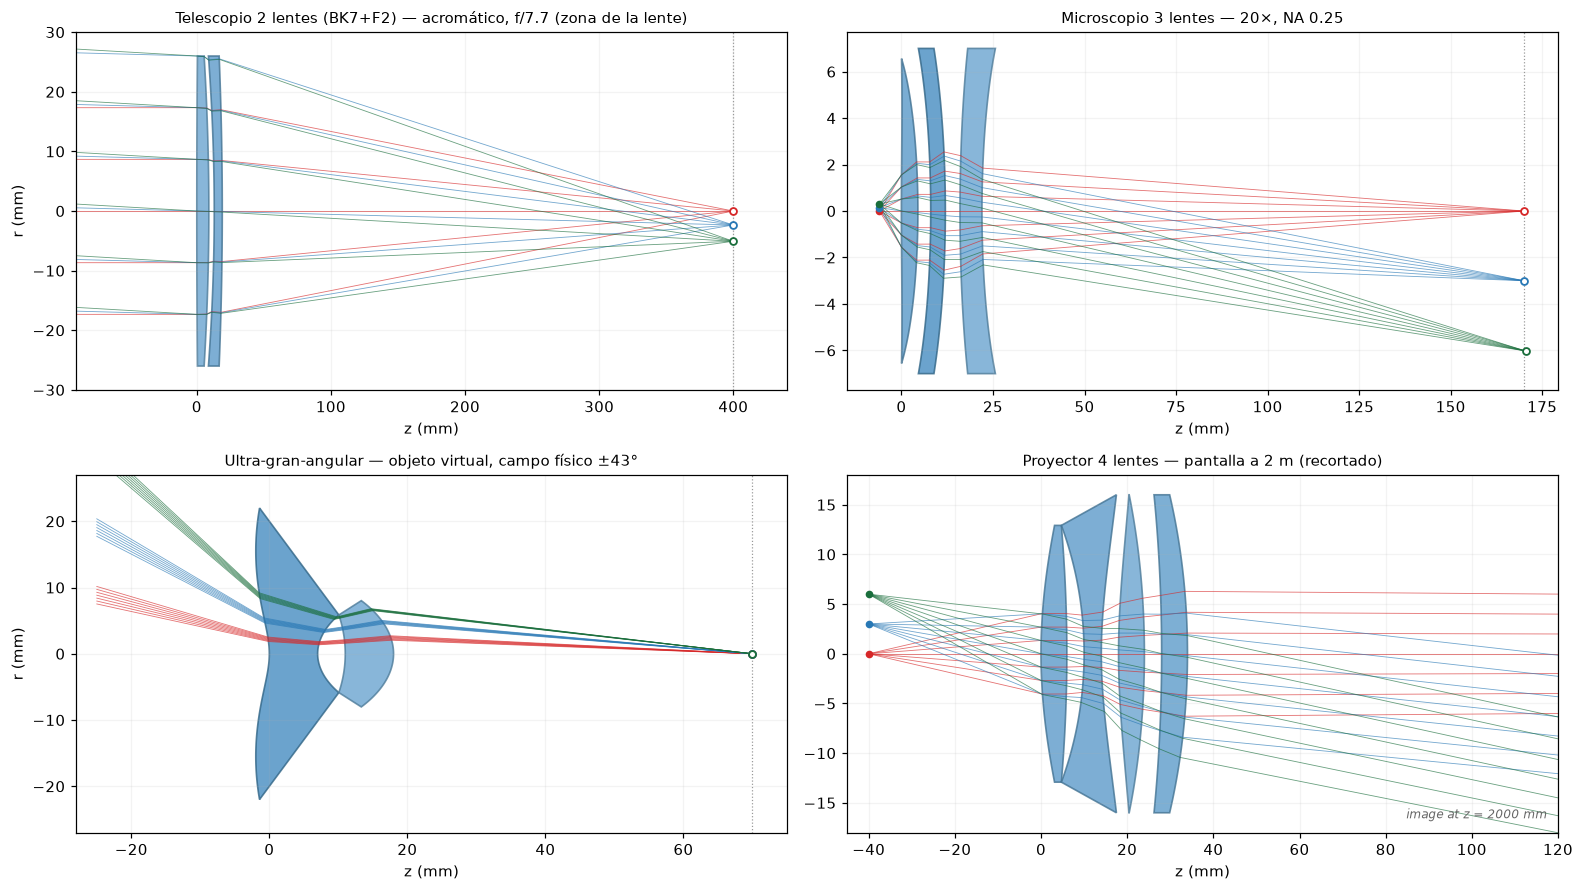

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 8.2))
draw_train(axes[0, 0], telescope, [0.0, 6000.0, 13000.0], TEL_NA,
           "Telescopio 2 lentes (BK7+F2) — acromático, f/7.7 (zona de la lente)",
           xlim=(-90.0, 440.0), ylim=(-30.0, 30.0))
draw_train(axes[0, 1], microscope, [0.0, 0.15, 0.3], MIC_NA,
           "Microscopio 3 lentes — 20×, NA 0.25")
draw_train(axes[1, 0], ultrawide, [np.sin(np.deg2rad(a)) for a in (15, 30, 43)],
           0.1, "Ultra-gran-angular — objeto virtual, campo físico ±43°",
           launch=-25.0, xlim=(-28.0, 75.0), ylim=(-27.0, 27.0))
draw_train(axes[1, 1], projector, [0.0, 3.0, 6.0], PRO_NA,
           "Proyector 4 lentes — pantalla a 2 m (recortado)",
           xlim=(-45.0, 120.0), ylim=(-18.0, 18.0))
for ax in axes[:, 0]:
    ax.set_ylabel("r (mm)")
fig.tight_layout()
plt.show()

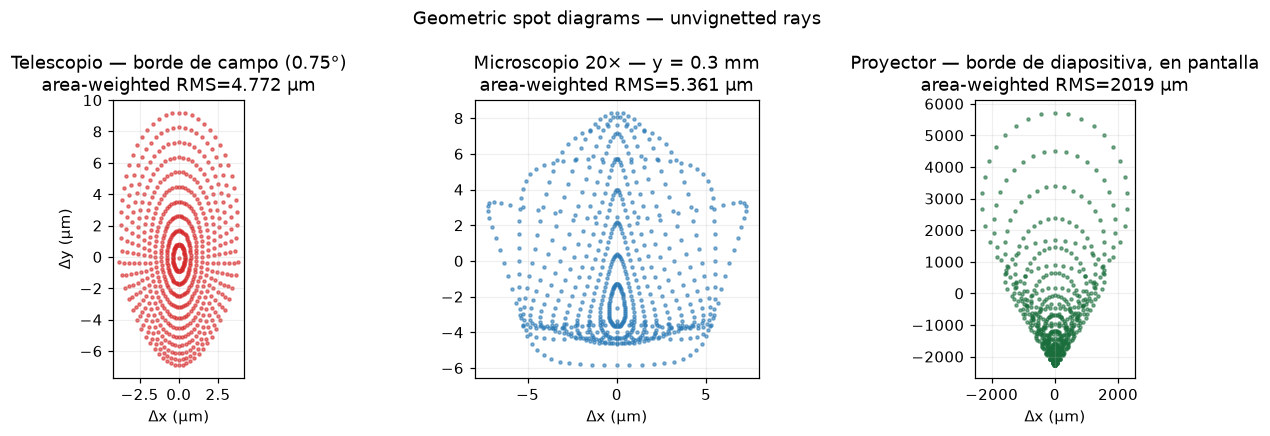

In [8]:
sampling = PupilSampling(kind="rings", radial=12, azimuth=64)
spots, spot_titles = [], []
for train, y, na, stop, title in [
    (telescope, 13000.0, TEL_NA, 0, "Telescopio — borde de campo (0.75°)"),
    (microscope, 0.3, MIC_NA, 0, "Microscopio 20× — y = 0.3 mm"),
    (projector, 6.0, PRO_NA, 3, "Proyector — borde de diapositiva, en pantalla"),
]:
    pupil = trace_pupil(SequentialTracer(train.to_system()), FieldPoint(y=y),
                        na_object_sine=na, sampling=sampling, stop_index=stop)
    spots.append(spot_data(pupil)); spot_titles.append(title)
fig = plots.spots_figure(spots, colors=FIELD_COLORS, titles=spot_titles)
plt.show()

Telescopio         cobertura 100.0%   máx    0.063 µm = 0.0009 %
Microscopio 20×    cobertura 100.0%   máx   27.460 µm = 0.3236 %


Proyector ~32×     cobertura 100.0%   máx 2688.697 µm = 1.0018 %


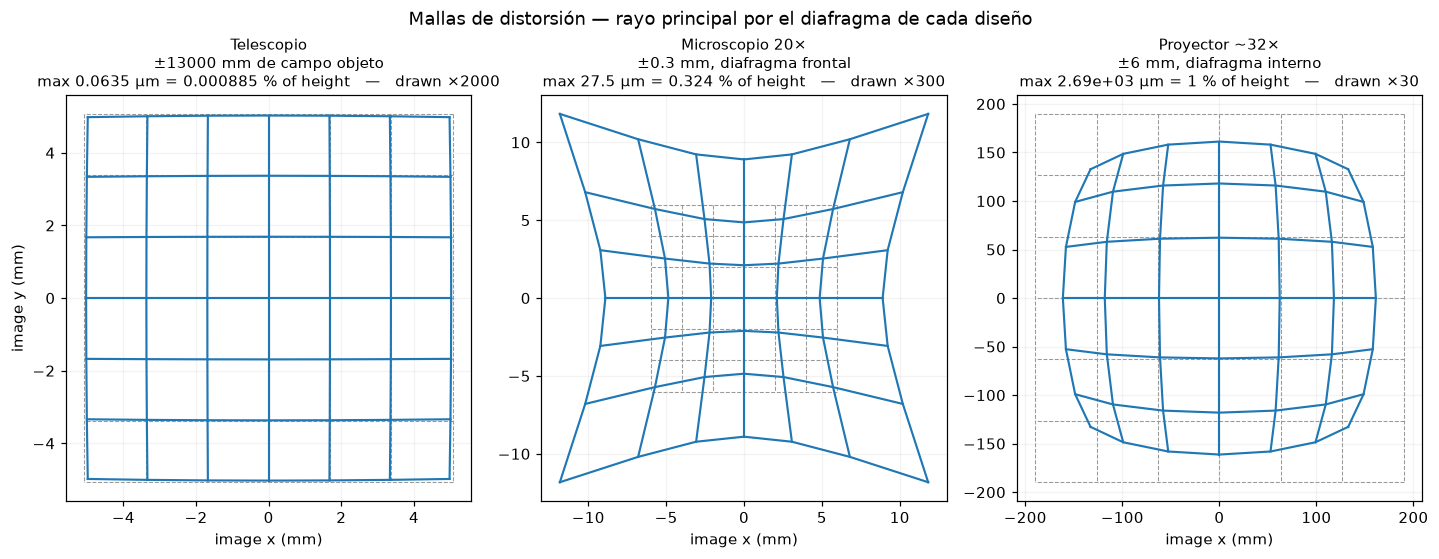

In [9]:
grids, titles, exags = [], [], []
for train, title, half, exag, stop in [
    (telescope, "Telescopio\n±13000 mm de campo objeto", 13000.0, 2000.0, 0),
    (microscope, "Microscopio 20×\n±0.3 mm, diafragma frontal", 0.3, 300.0, 0),
    (projector, "Proyector ~32×\n±6 mm, diafragma interno", 6.0, 30.0, 3),
]:
    grid = distortion_grid(SequentialTracer(train.to_system()),
                           magnification=train.gt, half_field=half, n=7,
                           stop_index=stop)
    print(f"{title.splitlines()[0]:18s} cobertura {grid.valid_fraction:5.1%}   "
          f"máx {grid.max_distortion_um:8.3f} µm = "
          f"{grid.max_relative_distortion_percent:.4f} %")
    grids.append(grid); titles.append(title); exags.append(exag)

fig = plots.distortion_grids_figure(
    grids, titles=titles, exaggerations=exags,
    suptitle="Mallas de distorsión — rayo principal por el diafragma de cada diseño")
plt.show()

## 6. El microscopio imprimible — una sola resina, leída de archivo

Para imprimir en casa: tres lentes del **mismo material**, la resina
Formlabs Clear V4, cuyo ajuste de Cauchy a la tabla medida del fabricante
(486–656 nm) vive en `data/materials/formlabs_resins.csv` — datos, no código — y entra
por `raytracer.io.read_materials`. Especificación casera: 10×, NA 0.15,
distancia de trabajo 8 mm, tubo de 160 mm.

Con un solo material no hay pareja corona/flint: el reparto de potencias no
puede cancelar el color axial, así que se optimiza sin `AxialColor` y el
color residual se **mide y declara**. El remedio práctico en casa es
iluminar con un LED cuasi-monocromático (el diseño es exacto en la línea d;
un LED verde de ~10 nm de ancho lo usa donde es perfecto).

n de la resina en las líneas F/d/C: [1.51404, 1.5084, 1.50488]
medios: ['AIR', 'FORMLABS_CLEAR_V4', 'AIR', 'FORMLABS_CLEAR_V4', 'AIR', 'FORMLABS_CLEAR_V4', 'AIR']


(M-1)_RMS = 1.56e-03   gt = -10.0436
distorsión: [0.3795 0.5384] %   sagita: 0.01227 mm
blur [4.46e-12 9.29e+00 1.86e+01] µm   (Airy en imagen ≈ 24.0 µm)
color axial F/C: -12.713 / +9.187 mm — declarado; con LED verde estrecho el diseño trabaja en su línea exacta


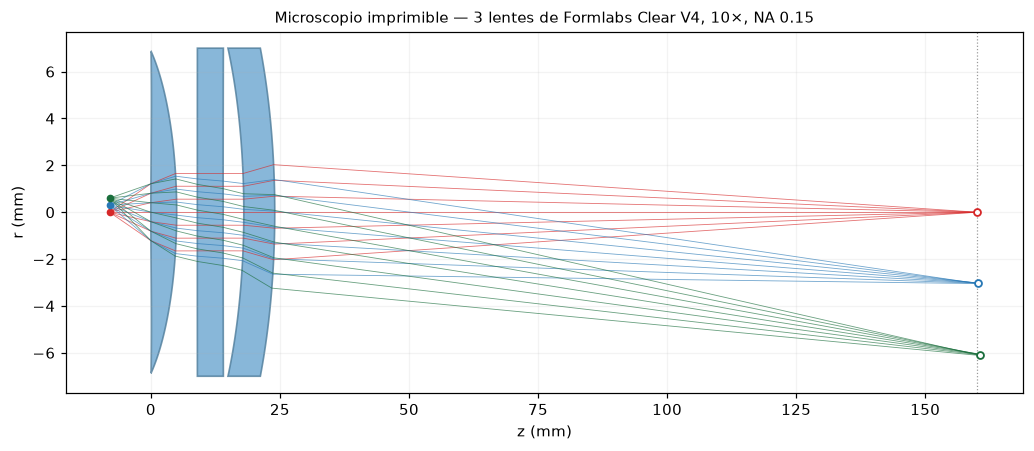

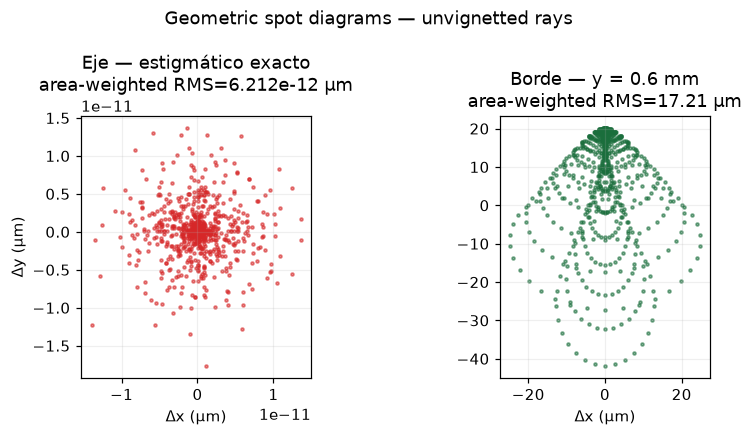

In [10]:
RESIN = LIB["FORMLABS_CLEAR_V4"]
print("n de la resina en las líneas F/d/C:",
      [round(RESIN.index(w), 5) for w in (0.48613, WL, 0.65627)])

printable0 = read_train(
    DATA / "optical_systems/microscopes/formlabs_clear_10x.json", materials=LIB)
print("medios:", [m.name for m in printable0.media])

PRN_NA, PRN_FIELDS = 0.15, (0.3, 0.6)
printable_fit = optimize_train(
    printable0,
    [Aplanatism(),
     TargetMagnification(value=-10.0, weight=0.05),
     Distortion(heights=PRN_FIELDS, weight=1.0),
     FlatImageSurface(heights=(0.0, *PRN_FIELDS), weight=1.0)],
    na_object_sine=PRN_NA, samples=13, bounds=(-3.5e3, 3.5e3), **POLISH,
)
printable = printable_fit.train
ctx = EvaluationContext(printable, na_object_sine=PRN_NA, samples=9)
dist = Distortion(heights=PRN_FIELDS).residuals(ctx)
color = AxialColor().residuals(ctx)
locus = printable_fit.image_surface
airy_um = 0.61 * WL / (PRN_NA / abs(printable.gt))
print(f"(M-1)_RMS = {ctx.report().map_rms:.2e}   gt = {printable.gt:+.4f}")
print(f"distorsión: {np.array2string(dist*100, precision=4)} %   "
      f"sagita: {locus.max_sagitta:.5f} mm")
print(f"blur {np.array2string(locus.blur_rms_um, precision=2)} µm"
      f"   (Airy en imagen ≈ {airy_um:.1f} µm)")
print(f"color axial F/C: {color[0]:+.3f} / {color[1]:+.3f} mm "
      f"— declarado; con LED verde estrecho el diseño trabaja en su línea exacta")

fig, ax = plt.subplots(figsize=(9.5, 4.2))
draw_train(ax, printable, [0.0, 0.3, 0.6], PRN_NA,
           "Microscopio imprimible — 3 lentes de Formlabs Clear V4, 10×, NA 0.15")
ax.set_ylabel("r (mm)")
fig.tight_layout()
plt.show()

prn_spots = [spot_data(trace_pupil(SequentialTracer(printable.to_system()),
                                   FieldPoint(y=y), na_object_sine=PRN_NA,
                                   sampling=sampling, stop_index=0))
             for y in (0.0, 0.6)]
fig = plots.spots_figure(prn_spots, colors=["#d62728", "#1a6e3c"],
                         titles=["Eje — estigmático exacto", "Borde — y = 0.6 mm"])
plt.show()

---

**Dónde vive cada pieza.** Los medios llenan el espacio y las superficies
los delimitan: un tren se declara con `StigmaticTrain(media=..., ...)`,
donde cada medio es un `Material` — el medio de índice constante
(`ConstantIndex`, un float basta) o una ley de dispersión real. Las
restricciones y `optimize_train`: `raytracer.optimize` (una restricción
nueva es una subclase de `Constraint`, como el `VirtualObjectAplanatism` de
arriba). Los diseños viven como datos en `data/optical_systems/<clase>/` y
entran por `raytracer.io.read_train`; el catálogo de materiales, en
`data/materials/formlabs_resins.csv` vía `read_materials`. Los cuerpos de
lente y su color por densidad: `raytracer.viz.bodies`. La teoría del
aplanatismo: notebook `stigmatism_and_aplanatism.ipynb` y el README.